In [71]:
import pygyre as pg
import numpy as np
import scipy as cp
from scipy import integrate
import matplotlib.pyplot as plt
from TDECalculator import TDECalculator

In [72]:
Masses, Gammas = np.loadtxt('M-gamma.txt', unpack=True)

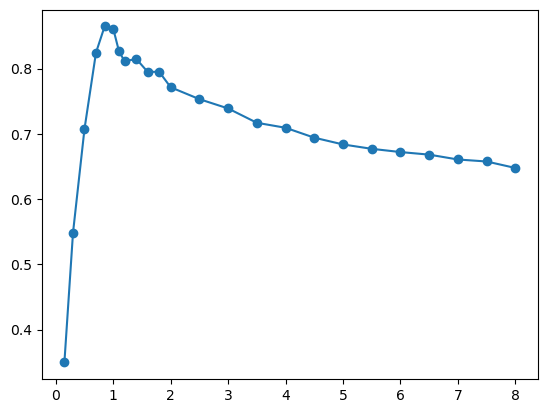

In [73]:
plt.plot(Masses, Gammas, '-o')

In [74]:
import os

def get_folder_names(directory_path):
    """
    Returns a list of folder names within the specified directory.
    """
    folder_names = []
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)
        if os.path.isdir(item_path):
            folder_names.append(item)
    return folder_names

masses = np.sort(get_folder_names('star-files')).tolist()

import re

def parse_numbers(strings):
    numbers = []
    pattern = re.compile(r'-?\d+(?:p\d+|\.\d+)?')

    for s in strings:
        matches = pattern.findall(s)
        for match in matches:
            # Replace 'p' with '.' to convert formats like 0p15 to 0.15
            number_str = match.replace('p', '.')
            try:
                numbers.append(float(number_str))
            except ValueError:
                pass  # Skip malformed numbers

    return np.array(numbers)

mass_vals = parse_numbers(masses)

In [75]:
Mbh = 1e6
a = 0.5
n = 1000
beta_f = 12.0

In [76]:
def rps_equal_beta(masses, Mbh):
    Rps = []
        
    for star_name in masses:
        summary = pg.read_output(f"star-files/{star_name}/summary.h5")
        detail0 = pg.read_output(f"star-files/{star_name}/detail.l2.n+0.h5")
        r   = detail0['x']          # radial grid (in R_star units)
        rho = detail0['rho']        # density (g/cm^3)
        M_r       = detail0['M_r']       # enclosed mass profile

        # Convert quantities to dimensionless units
        Mstar      = summary['M_star'][0] / 1.9884e33  # solar masses
        mass_ratio = Mstar / Mbh
        Rstar      = (summary['R_star'][0]/100) / (Mbh*1476.55)
        Rtidal     = Rstar / mass_ratio**(1/3)

        rho_avg = np.mean(rho)

        beta_crit = 0.5 * (rho[0] / rho_avg)**(1/3)

        rp = Rtidal / (beta_crit) 
        Rps.append(rp)
    
    return Rps

In [77]:
Rps = rps_equal_beta(masses, Mbh)

In [80]:
Rps

[18.40153682764219,
 27.49155841770932,
 41.565493205414285,
 53.24009446847726,
 55.90802098697754,
 71.25163507157494,
 75.194437769521,
 74.97691686277543,
 77.62708527038117,
 80.98548874784144,
 87.56555000513849,
 88.19422303102196,
 94.46282204862064,
 104.87646850410802,
 102.67220323070292,
 106.01031454429183,
 108.03429285821584,
 111.42019817031841,
 114.00130754009834,
 115.13410376499495,
 118.0449571910225,
 119.59274050284105,
 123.88876300876701,
 128.05497469695086]

In [78]:
def gammas(masses, label, Mbh, Rps, a, n):
    gammas = []

    for i in range(len(masses)):
        calc = TDECalculator(masses[i], label, Mbh, Rps[i], a, n)

        gamma = np.max((calc.TidalEnergy) / np.abs(calc.U))
        gammas.append(gamma)

    return gammas
    

In [79]:
g = gammas(masses, 'rel', Mbh, Rps, a, n)

RuntimeError: No TDE detected; tidal energy never exceeds threshold.

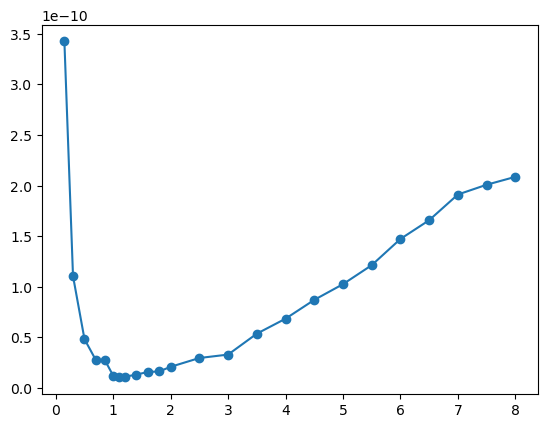

In [ ]:
plt.plot(mass_vals, g, '-o')

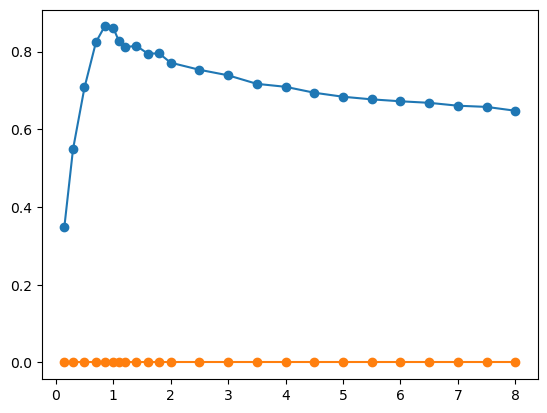

In [ ]:
plt.plot(Masses, Gammas, '-o')
plt.plot(mass_vals, g, '-o')